# FOMO-300K Dataset Exploration

This notebook explores the FOMO-300K dataset for normative modeling of dementia.

**Dataset**: FOMO-300K (Federated cOllaborative Learning for Medical iMaging Opendata)  
**Source**: Multi-dataset aggregation of 18+ public neuroimaging datasets  
**Total Records**: 82,680 (before filtering)  
**Focus**: Healthy controls aged ≥45 years with MRI at 1.5T or 3T  
**Session Selection**: First session only per subject per dataset  

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
import json
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
import os 
os.chdir(Path().absolute().parent)

## 1. Load Raw FOMO-300K Data

In [3]:
# Load participants data (82,680 records)
print("Loading FOMO-300K participants data...")
participants = pd.read_csv('data/FOMO-300K/participants.tsv', sep='\t')

print(f"Total records: {len(participants):,}")
print(f"Total columns: {len(participants.columns):,}")
print(f"Unique participants: {participants['participant_id'].nunique():,}")
print(f"\nColumns: {list(participants.columns)}")
print(f"\nFirst 5 rows:")
print(participants.head())

Loading FOMO-300K participants data...
Total records: 82,678
Total columns: 7
Unique participants: 4,919

Columns: ['dataset', 'participant_id', 'session_id', 'sex', 'age', 'handedness', 'group']

First 5 rows:
              dataset participant_id session_id sex age handedness    group
0  PT001_ClevelandCCF         sub-01     ses-01   M  30        NaN  Control
1  PT001_ClevelandCCF         sub-02     ses-01   F  29        NaN  Control
2  PT001_ClevelandCCF         sub-03     ses-01   F  57        NaN  Control
3  PT001_ClevelandCCF         sub-04     ses-01   F  45        NaN  Control
4  PT001_ClevelandCCF         sub-05     ses-01   M  33        NaN  Control


In [4]:
# Load MRI scanner information (large file >50MB)
print("\nLoading MRI scanner information (this may take a moment)...")
try:
    mri_info = pd.read_csv('data/FOMO-300K/mri_info.tsv', sep='\t', low_memory=False)
    print(f"MRI info records: {len(mri_info):,}")
    print(f"MRI info columns: {list(mri_info.columns)}")
    print(f"\nFirst 5 rows:")
    print(mri_info.head())
except Exception as e:
    print(f"Note: Could not load full mri_info.tsv. Error: {e}")
    print("Will proceed with participants.tsv only and handle MRI info separately if needed.")
    mri_info = None


Loading MRI scanner information (this may take a moment)...
MRI info records: 318,877
MRI info columns: ['dataset', 'participant_id', 'session_id', 'filename', 'Modality', 'MagneticFieldStrength', 'Manufacturer', 'ManufacturersModelName', 'SoftwareVersions', 'MRAcquisitionType', 'SeriesDescription', 'ProtocolName', 'ScanningSequence', 'SequenceVariant', 'ScanOptions', 'SequenceName', 'EchoTime', 'SliceThickness', 'RepetitionTime', 'InversionTime', 'FlipAngle']

First 5 rows:
              dataset participant_id session_id  \
0  PT001_ClevelandCCF         sub-01     ses-01   
1  PT001_ClevelandCCF         sub-02     ses-01   
2  PT001_ClevelandCCF         sub-03     ses-01   
3  PT001_ClevelandCCF         sub-04     ses-01   
4  PT001_ClevelandCCF         sub-05     ses-01   

                                      filename Modality MagneticFieldStrength  \
0  sub-01/ses-01/anat/sub-01_ses-01_T1w.nii.gz       MR                   3.0   
1  sub-02/ses-01/anat/sub-02_ses-01_T1w.nii.gz    

## 2. Dataset Components Analysis

In [5]:
# Extract dataset identifier from dataset column
participants['dataset_code'] = participants['dataset'].str.split('_').str[0]

print("Dataset distribution (unique participants per dataset):")
unique_participants_per_dataset = participants.groupby('dataset_code')['participant_id'].nunique().sort_index()
print(unique_participants_per_dataset)
print(f"\nTotal unique datasets: {participants['dataset_code'].nunique()}")
print(f"Total unique dataset-site combinations: {participants['dataset'].nunique()}")
total_unique_participants = unique_participants_per_dataset.sum()
print(f"Total unique participants across all datasets: {total_unique_participants:,}")

Dataset distribution (unique participants per dataset):
dataset_code
PT001      31
PT002      82
PT003      51
PT004     163
PT005     973
PT006     105
PT007      53
PT008      51
PT009    2611
PT010     592
PT011      32
PT012     203
PT013     162
PT014    1498
PT015     750
PT016    1639
PT017      13
PT018    3847
PT019      45
PT020    1113
PT021     584
PT022     180
PT023     833
PT024     208
PT025    1135
PT026      50
PT027    1327
PT028     416
PT029     150
PT030    2742
PT031     594
PT032      40
PT033     177
PT034     426
PT035    1430
PT036     232
PT037     131
Name: participant_id, dtype: int64

Total unique datasets: 37
Total unique dataset-site combinations: 920
Total unique participants across all datasets: 24,669


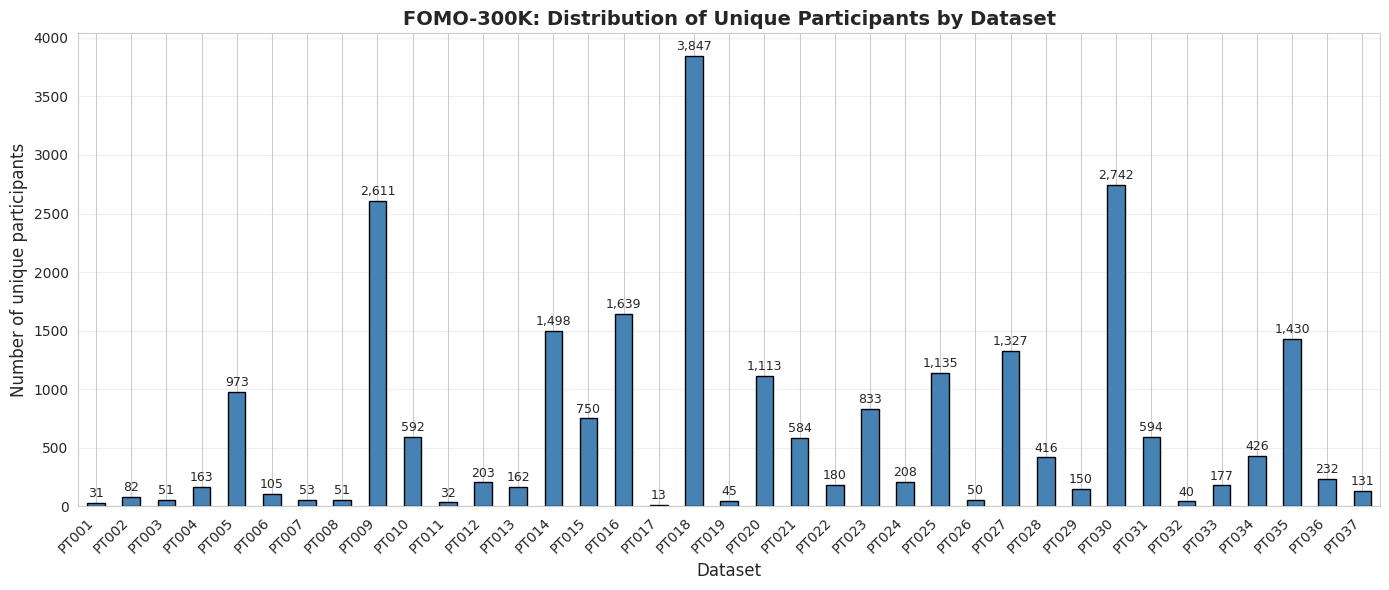


Top 10 dataset-site combinations (by unique participants):
dataset
PT018_HBN                             3847
PT009_BraTS-GEN                       2611
PT030_OpenNeuro/ds004889              1715
PT016_GSP                             1639
PT014_CoRR                            1498
PT035_Yale_Brain_Mets_Longitudinal    1430
PT027_NKI                             1327
PT030_OpenNeuro/ds004169              1202
PT025_MGH_Wild                        1135
PT020_HCP_Wu_Minn                     1113
Name: participant_id, dtype: int64


In [6]:
# Visualize dataset contributions
fig, ax = plt.subplots(figsize=(14, 6))
unique_participants_per_dataset.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('Dataset', fontsize=12)
ax.set_ylabel('Number of unique participants', fontsize=12)
ax.set_title('FOMO-300K: Distribution of Unique Participants by Dataset', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(unique_participants_per_dataset.values):
    ax.text(i, v + 50, f'{v:,}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

print("\nTop 10 dataset-site combinations (by unique participants):")
unique_per_full_dataset = participants.groupby('dataset')['participant_id'].nunique().sort_values(ascending=False).head(10)
print(unique_per_full_dataset)

## 3. Demographics Analysis (Before Filtering)

In [7]:
# Age distribution (all records)
# Convert age to numeric in the dataframe itself
participants['age'] = pd.to_numeric(participants['age'], errors='coerce')
age_all = participants['age']

AGE_MIN_VALID = 10
AGE_MAX_VALID = 110

n_before = len(participants)
outlier_mask = participants['age'].notna() & (
    (participants['age'] <= AGE_MIN_VALID) | (participants['age'] > AGE_MAX_VALID)
)
n_removed = int(outlier_mask.sum())

participants = participants.loc[~outlier_mask].copy()

print(f"Age outliers rimossi: {n_removed:,}")
print(f"Record rimanenti: {len(participants):,} (da {n_before:,})")


print("Age distribution (all records):")
print(f"  Range: {age_all.min():.0f} - {age_all.max():.0f} years")
print(f"  Mean: {age_all.mean():.1f} ± {age_all.std():.1f}")
print(f"  Median: {age_all.median():.0f}")
print(f"  Missing: {age_all.isna().sum():,}")



# Age distribution by dataset
print("\nAge range by dataset (top 10):")
age_by_dataset = participants.groupby('dataset_code')['age'].agg(['min', 'max', 'mean', 'count'])
age_by_dataset = age_by_dataset.sort_values('count', ascending=False).head(10)
print(age_by_dataset)

Age outliers rimossi: 5,246
Record rimanenti: 77,432 (da 82,678)
Age distribution (all records):
  Range: -17 - 100 years
  Mean: 35.3 ± 21.8
  Median: 26
  Missing: 22,123

Age range by dataset (top 10):
                    min         max       mean  count
dataset_code                                         
PT030         10.010000  100.000000  30.916084  29484
PT035         15.000000   93.000000  60.946546  11842
PT014         10.100000   88.000000  27.323548   2675
PT018         10.002623   22.000228  13.365241   1721
PT027         11.000000   85.000000  36.959271   1645
PT016         19.000000   35.000000  21.541401   1570
PT025         12.000000   94.000000  60.209364   1132
PT031         17.000000   27.000000  19.980639   1033
PT033         18.300000   63.700000  29.471018    835
PT021         19.980835   86.318960  48.608614    564


In [8]:
# Sex distribution
print("Sex distribution (all records):")
sex_counts = participants['sex'].value_counts()
for sex, count in sex_counts.items():
    print(f"  {sex}: {count:,} ({count/len(participants)*100:.1f}%)")

# Handedness distribution
print("\nHandedness distribution:")
hand_counts = participants['handedness'].value_counts(dropna=False)
print(hand_counts)
print(f"Missing handedness: {participants['handedness'].isna().sum():,} ({participants['handedness'].isna().sum()/len(participants)*100:.1f}%)")

Sex distribution (all records):
  F: 32,059 (41.4%)
  M: 26,969 (34.8%)

Handedness distribution:
handedness
NaN    64925
R      11483
L        937
A         87
Name: count, dtype: int64
Missing handedness: 64,925 (83.8%)


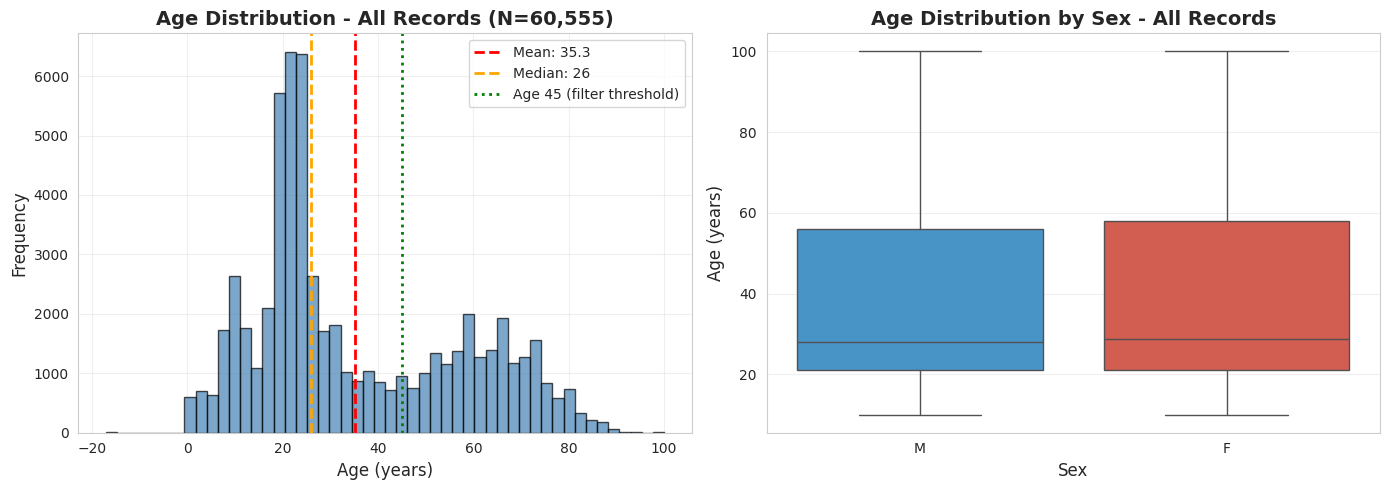

In [9]:
# Visualize age distribution (all records)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall age histogram
axes[0].hist(age_all.dropna(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(age_all.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {age_all.mean():.1f}')
axes[0].axvline(age_all.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {age_all.median():.0f}')
axes[0].axvline(45, color='green', linestyle=':', linewidth=2, label='Age 45 (filter threshold)')
axes[0].set_xlabel('Age (years)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title(f'Age Distribution - All Records (N={len(age_all.dropna()):,})', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Age by sex
sex_palette = {'M': '#3498db', 'F': '#e74c3c'}
participants_plot = participants[participants['age'].notna()].copy()
sns.boxplot(data=participants_plot, x='sex', y='age', palette=sex_palette, ax=axes[1])
axes[1].set_xlabel('Sex', fontsize=12)
axes[1].set_ylabel('Age (years)', fontsize=12)
axes[1].set_title('Age Distribution by Sex - All Records', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 4. Group/Diagnosis Analysis

In [10]:
# Group distribution
print("Group/diagnosis distribution:")
group_counts = participants['group'].value_counts()
for group, count in group_counts.items():
    print(f"  {group}: {count:,} ({count/len(participants)*100:.1f}%)")

# Control subjects by dataset
print("\nControl subjects by dataset:")
controls_by_dataset = participants[participants['group'] == 'Control']['dataset_code'].value_counts().sort_index()
print(controls_by_dataset)
print(f"\nTotal control subjects: {(participants['group'] == 'Control').sum():,}")

Group/diagnosis distribution:
  Control: 39,326 (50.8%)
  Brain Tumor: 15,228 (19.7%)
  Stroke: 2,500 (3.2%)
  control: 1,743 (2.3%)
  Memory complaints: 1,132 (1.5%)
  Typically Developing: 543 (0.7%)
  Major depressive disorder: 232 (0.3%)
  AD: 227 (0.3%)
  Nondemented: 190 (0.2%)
  ADHD-Combined: 188 (0.2%)
  CN: 177 (0.2%)
  Brain aneurysm(s): 168 (0.2%)
  Psychiatric illness: 149 (0.2%)
  Demented: 146 (0.2%)
  Anxiety disorders, disruptive mood dysregulation disorder, or Attention deficit hyperactivity disorder: 139 (0.2%)
  nondemented: 135 (0.2%)
  ADHD-Inattentive: 129 (0.2%)
  CONTROL: 125 (0.2%)
  FTD: 123 (0.2%)
  Intracranial aneurysms: 122 (0.2%)
  Parkinson’s disease: 117 (0.2%)
  Disruptive mood dysregulation disorder or attention-deficit hyperactivity disorder: 117 (0.2%)
  Synaesthesia: 102 (0.1%)
  HC: 87 (0.1%)
  Autism Spectrum Disorder: 79 (0.1%)
  Cocaine use disorder - Treatment: 79 (0.1%)
  Cocaine use disorder: 74 (0.1%)
  Traumatic brain injury: 74 (0.1%)
  

In [11]:
# Cross-tabulation: dataset × group
print("Dataset × Group cross-tabulation (top 15 datasets):")
top_datasets = participants['dataset_code'].value_counts().head(15).index
crosstab = pd.crosstab(
    participants[participants['dataset_code'].isin(top_datasets)]['dataset_code'], 
    participants[participants['dataset_code'].isin(top_datasets)]['group']
)
print(crosstab)

Dataset × Group cross-tabulation (top 15 datasets):
group          AD  ADHD  ADHD-Combined  ADHD-Hyperactive/Impulsive  \
dataset_code                                                         
PT005           0     0            188                          12   
PT009           0     0              0                           0   
PT010         227     0              0                           0   
PT014           0     0              0                           0   
PT015           0     0              0                           0   
PT016           0     0              0                           0   
PT020           0     0              0                           0   
PT025           0     0              0                           0   
PT030           0    41              0                           0   
PT033           0     0              0                           0   
PT034           0     0              0                           0   
PT035           0     0              0

## 5. Session Analysis

In [12]:
# Session distribution
print("Session distribution:")
session_counts = participants['session_id'].value_counts().sort_index()
print(session_counts.head(10))
print(f"\nTotal unique sessions: {participants['session_id'].nunique()}")

# Subjects with multiple sessions
sessions_per_subject = participants.groupby('participant_id')['session_id'].nunique()
print("\nSubjects by number of sessions:")
print(sessions_per_subject.value_counts().sort_index())
print(f"\nSubjects with multiple sessions: {(sessions_per_subject > 1).sum():,}")

Session distribution:
session_id
ses-01    55461
ses-02     7823
ses-03     3344
ses-04     1909
ses-05     1382
ses-06     1004
ses-07      819
ses-08      696
ses-09      609
ses-10      518
Name: count, dtype: int64

Total unique sessions: 68

Subjects by number of sessions:
session_id
1     2271
2      377
3      326
4      206
5      227
6      130
7      103
8       75
9       71
10      62
11      45
12      32
13      44
14      30
15      36
16      22
17      15
18      21
19      29
20      20
21       6
22      13
23      10
24       5
25      14
26       4
27       7
28      10
29       5
30       7
31       4
32       1
33       2
34       6
35       5
36       1
37       3
38       3
40       1
42       1
47       1
48       1
49       1
66       1
68       1
Name: count, dtype: int64

Subjects with multiple sessions: 1,984


## 6. MRI Scanner Information Analysis

In [13]:
# Merge participants with MRI scanner info
if mri_info is not None:
    print("Merging participants with MRI scanner information...")
    data_merged = participants.merge(
        mri_info,
        on=['dataset', 'participant_id', 'session_id'],
        how='left'
    )
    print(f"Merged records: {len(data_merged):,}")
    print(f"Records with MRI info: {data_merged['MagneticFieldStrength'].notna().sum():,}")
    
    # Field strength distribution
    field_strength = pd.to_numeric(data_merged['MagneticFieldStrength'], errors='coerce')
    print("\nMagnetic Field Strength distribution:")
    print(f"  Non-null values: {field_strength.notna().sum():,} / {len(data_merged):,}")
    if field_strength.notna().sum() > 0:
        print(f"  Range: {field_strength.min():.2f}T - {field_strength.max():.2f}T")
        print(f"  Mean: {field_strength.mean():.2f}T ± {field_strength.std():.2f}T")
        print("\n  Distribution:")
        fs_counts = field_strength.value_counts().sort_index()
        for fs, count in fs_counts.items():
            print(f"    {fs}T: {count:,} ({count/field_strength.notna().sum()*100:.1f}%)")
        
        # Count records with field strength ≤ 3T
        fs_3t_or_less = field_strength <= 3.0
        print(f"\n  Records with field strength ≤3T: {fs_3t_or_less.sum():,} ({fs_3t_or_less.sum()/field_strength.notna().sum()*100:.1f}%)")
    
    # Scanner manufacturer
    if 'Manufacturer' in data_merged.columns:
        print("\nScanner Manufacturer distribution:")
        mfr_counts = data_merged['Manufacturer'].value_counts()
        for mfr, count in mfr_counts.head(10).items():
            print(f"  {mfr}: {count:,}")
else:
    print("MRI info not loaded. Using participants data only.")
    print("Assuming field strength information will be added separately.")
    data_merged = participants.copy()
    data_merged['MagneticFieldStrength'] = np.nan
    print("\nNote: MagneticFieldStrength column added but not populated.")
    print("Will need to process mri_info.tsv separately or in chunks.")

Merging participants with MRI scanner information...
Merged records: 290,203
Records with MRI info: 219,263

Magnetic Field Strength distribution:
  Non-null values: 218,996 / 290,203
  Range: 0.30T - 15000.00T
  Mean: 9.91T ± 323.59T

  Distribution:
    0.3T: 2,274 (1.0%)
    0.7T: 21 (0.0%)
    1.16T: 52 (0.0%)
    1.4939999580383T: 1 (0.0%)
    1.494T: 905 (0.4%)
    1.5T: 31,157 (14.2%)
    2.8936200141907T: 34 (0.0%)
    3.0T: 173,537 (79.2%)
    3.95064T: 1,342 (0.6%)
    4.0T: 293 (0.1%)
    6.98T: 3,162 (1.4%)
    7.0T: 6,025 (2.8%)
    9.4T: 86 (0.0%)
    10.5T: 5 (0.0%)
    15000.0T: 102 (0.0%)

  Records with field strength ≤3T: 207,981 (95.0%)

Scanner Manufacturer distribution:
  Siemens: 184,223
  Philips: 20,301
  GE: 11,188
  Ge medical systems: 4,397
  SIEMENS: 2,737
  Ningbo Xingaoyi: 2,230
  GE MEDICAL SYSTEMS: 644
  Brucker: 293
  Philips Medical Systems: 284
  General Electrics: 104


## 7. Apply Filtering Criteria

In [14]:
excluded_datasets = ["PT002","PT021","PT029","PT019","PT_020"]  


print("=" * 80)
print("APPLYING FILTERING CRITERIA")
print("=" * 80)

# Start with all records
data_filtered = data_merged.copy()
print(f"\nStarting records: {len(data_filtered):,}")

# Filter 1: Only Control group
print("\n[Filter 1] Group == 'Control'")
data_filtered = data_filtered[data_filtered['group'] == 'Control']
print(f"  Remaining: {len(data_filtered):,} records ({len(data_filtered)/len(data_merged)*100:.1f}% of total)")

# Filter 2: Age >= 45
print("\n[Filter 2] Age >= 45")
data_filtered = data_filtered[data_filtered['age'] >= 45]
print(f"  Remaining: {len(data_filtered):,} records ({len(data_filtered)/len(data_merged)*100:.1f}% of total)")

# Filter 3: Field strength 1.5T or 3T only (if available)
if data_filtered['MagneticFieldStrength'].notna().sum() > 0:
    print("\n[Filter 3] MagneticFieldStrength 1.5T or 3.0T only")
    before_fs_filter = len(data_filtered)
    
    # Convert to numeric first
    data_filtered['MagneticFieldStrength'] = pd.to_numeric(data_filtered['MagneticFieldStrength'], errors='coerce')
    
    data_filtered = data_filtered[
        (data_filtered['MagneticFieldStrength'].isin([1.5, 3.0])) | 
        (data_filtered['MagneticFieldStrength'].isna())
    ]
    print(f"  Remaining: {len(data_filtered):,} records ({len(data_filtered)/len(data_merged)*100:.1f}% of total)")
    print(f"  (Note: {data_filtered['MagneticFieldStrength'].isna().sum():,} records have missing field strength)")
else:
    print("\n[Filter 3] MagneticFieldStrength 1.5T or 3.0T only - SKIPPED (no MRI info loaded)")
    print("  Note: This filter should be applied after loading mri_info.tsv")

# Filter 4: First session only per subject
print("\n[Filter 4] First session only per subject")
print(f"  Before: {len(data_filtered):,} records")

# Sort by dataset_code, participant_id and session_id, then take first session per subject per dataset
data_filtered_sorted = data_filtered.sort_values(['dataset_code', 'participant_id', 'session_id'])
data_filtered = data_filtered_sorted.groupby(['dataset_code', 'participant_id']).first().reset_index()

print(f"  After: {len(data_filtered):,} subjects (one session each per subject per dataset)")

if excluded_datasets:
    print(f"\n[Filter 5] Exclude specific datasets: {excluded_datasets}")
    before_exclude = len(data_filtered)
    data_filtered = data_filtered[~data_filtered['dataset_code'].isin(excluded_datasets)]
    print(f"  Remaining: {len(data_filtered):,} subjects ({len(data_filtered)/before_exclude*100:.1f}% of previous)")
else:
    print("\n[Filter 5] No datasets excluded (modify excluded_datasets list if needed)")

print("\n" + "=" * 80)
print(f">>> TOTAL FILTERED SUBJECTS: {len(data_filtered):,} <<<")
print("=" * 80)

APPLYING FILTERING CRITERIA

Starting records: 290,203

[Filter 1] Group == 'Control'
  Remaining: 147,355 records (50.8% of total)

[Filter 2] Age >= 45
  Remaining: 13,055 records (4.5% of total)

[Filter 3] MagneticFieldStrength 1.5T or 3.0T only
  Remaining: 12,541 records (4.3% of total)
  (Note: 7,361 records have missing field strength)

[Filter 4] First session only per subject
  Before: 12,541 records
  After: 1,179 subjects (one session each per subject per dataset)

[Filter 5] Exclude specific datasets: ['PT002', 'PT021', 'PT029', 'PT019', 'PT_020']
  Remaining: 859 subjects (72.9% of previous)

>>> TOTAL FILTERED SUBJECTS: 859 <<<


## 8. Filtered Dataset Analysis

In [15]:
# Demographics of filtered dataset
age_filtered = data_filtered['age']

print("Filtered Dataset Demographics:")
print(f"\nAge distribution:")
print(f"  N: {len(age_filtered):,}")
print(f"  Range: {age_filtered.min():.0f} - {age_filtered.max():.0f} years")
print(f"  Mean: {age_filtered.mean():.1f} ± {age_filtered.std():.1f}")
print(f"  Median: {age_filtered.median():.0f}")
print(f"  Q1-Q3: {age_filtered.quantile(0.25):.0f} - {age_filtered.quantile(0.75):.0f}")

print("\nSex distribution:")
sex_counts_filtered = data_filtered['sex'].value_counts()
for sex, count in sex_counts_filtered.items():
    print(f"  {sex}: {count:,} ({count/len(data_filtered)*100:.1f}%)")

print("\nDataset distribution (top 15):")
dataset_counts_filtered = data_filtered['dataset_code'].value_counts().head(15)
for dataset, count in dataset_counts_filtered.items():
    print(f"  {dataset}: {count:,} ({count/len(data_filtered)*100:.1f}%)")

if data_filtered['MagneticFieldStrength'].notna().sum() > 0:
    print("\nField strength distribution:")
    fs_filtered = data_filtered['MagneticFieldStrength'].value_counts().sort_index()
    for fs, count in fs_filtered.items():
        print(f"  {fs}T: {count:,} ({count/data_filtered['MagneticFieldStrength'].notna().sum()*100:.1f}%)")

Filtered Dataset Demographics:

Age distribution:
  N: 859
  Range: 45 - 89 years
  Mean: 62.9 ± 10.5
  Median: 62
  Q1-Q3: 54 - 71

Sex distribution:
  F: 514 (59.8%)
  M: 345 (40.2%)

Dataset distribution (top 15):
  PT030: 526 (61.2%)
  PT014: 190 (22.1%)
  PT034: 81 (9.4%)
  PT032: 20 (2.3%)
  PT033: 19 (2.2%)
  PT001: 15 (1.7%)
  PT036: 8 (0.9%)

Field strength distribution:
  1.5T: 85 (12.0%)
  3.0T: 621 (88.0%)


## 9. Visualizations - Filtered Data

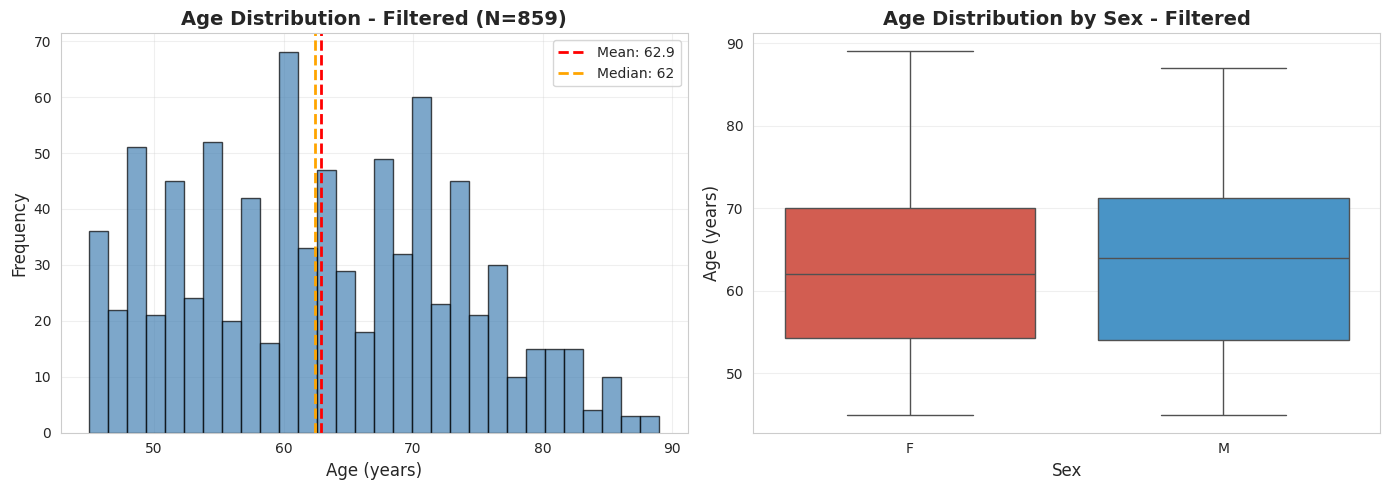

In [16]:
# Age distribution - filtered
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(age_filtered, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(age_filtered.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {age_filtered.mean():.1f}')
axes[0].axvline(age_filtered.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {age_filtered.median():.0f}')
axes[0].set_xlabel('Age (years)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title(f'Age Distribution - Filtered (N={len(age_filtered):,})', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot by sex
sex_palette = {'M': '#3498db', 'F': '#e74c3c'}
sns.boxplot(data=data_filtered, x='sex', y='age', palette=sex_palette, ax=axes[1])
axes[1].set_xlabel('Sex', fontsize=12)
axes[1].set_ylabel('Age (years)', fontsize=12)
axes[1].set_title('Age Distribution by Sex - Filtered', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

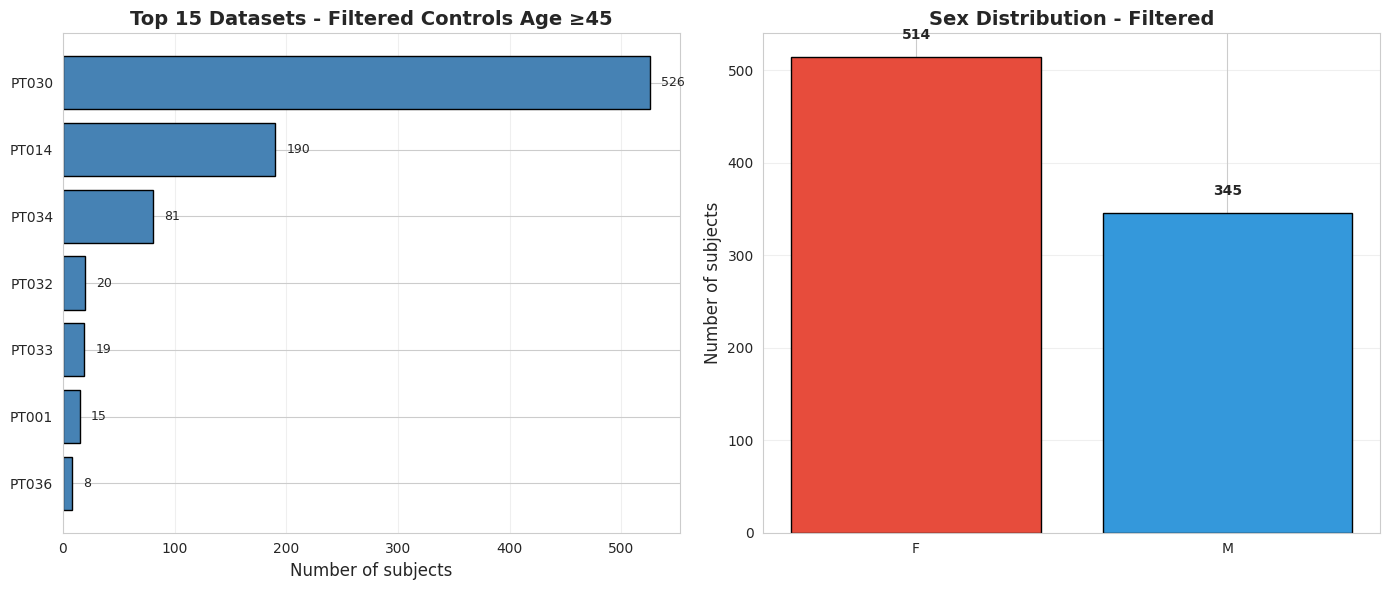

In [17]:
# Dataset contribution - filtered
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 15 datasets
top15_datasets = data_filtered['dataset_code'].value_counts().head(15)
axes[0].barh(range(len(top15_datasets)), top15_datasets.values, color='steelblue', edgecolor='black')
axes[0].set_yticks(range(len(top15_datasets)))
axes[0].set_yticklabels(top15_datasets.index)
axes[0].set_xlabel('Number of subjects', fontsize=12)
axes[0].set_title('Top 15 Datasets - Filtered Controls Age ≥45', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='x')
axes[0].invert_yaxis()
for i, v in enumerate(top15_datasets.values):
    axes[0].text(v + 10, i, str(v), va='center', fontsize=9)

# Sex distribution
sex_counts = data_filtered['sex'].value_counts()
colors = [sex_palette.get(sex, 'gray') for sex in sex_counts.index]
axes[1].bar(range(len(sex_counts)), sex_counts.values, color=colors, edgecolor='black')
axes[1].set_xticks(range(len(sex_counts)))
axes[1].set_xticklabels(sex_counts.index)
axes[1].set_ylabel('Number of subjects', fontsize=12)
axes[1].set_title('Sex Distribution - Filtered', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(sex_counts.values):
    axes[1].text(i, v + 20, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

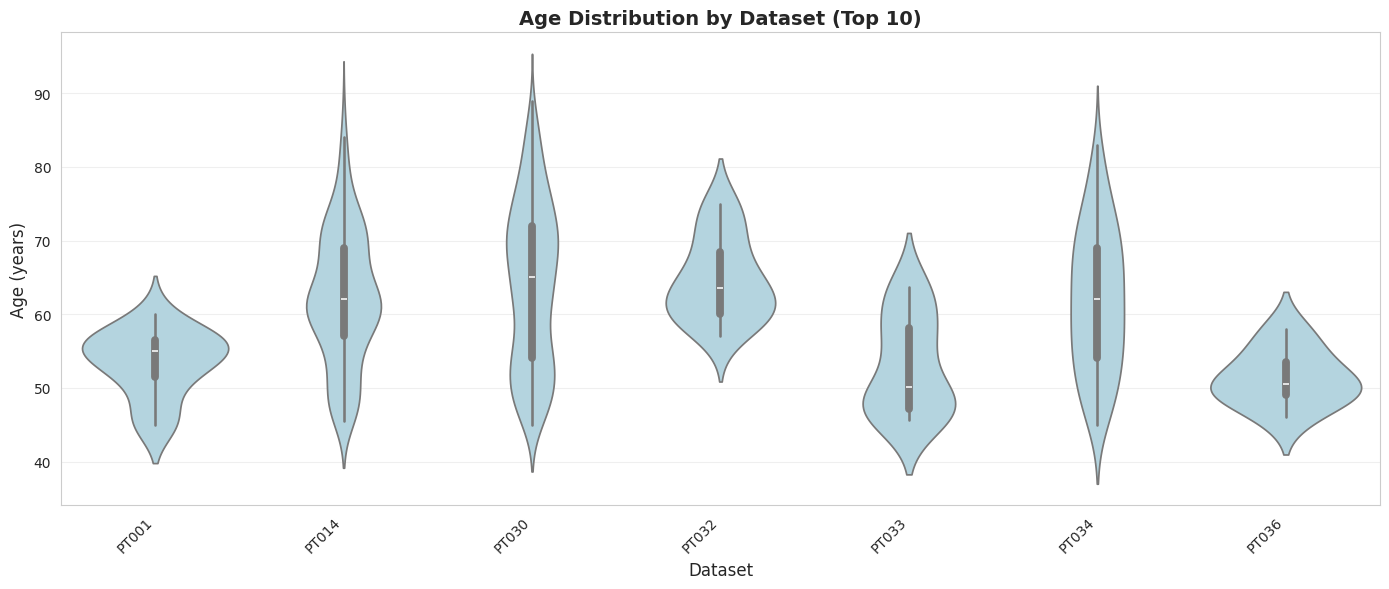

In [18]:
# Age distribution by top datasets
top10_datasets = data_filtered['dataset_code'].value_counts().head(10).index
data_top10 = data_filtered[data_filtered['dataset_code'].isin(top10_datasets)]

fig, ax = plt.subplots(figsize=(14, 6))
sns.violinplot(data=data_top10, x='dataset_code', y='age', ax=ax, color='lightblue')
ax.set_xlabel('Dataset', fontsize=12)
ax.set_ylabel('Age (years)', fontsize=12)
ax.set_title('Age Distribution by Dataset (Top 10)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

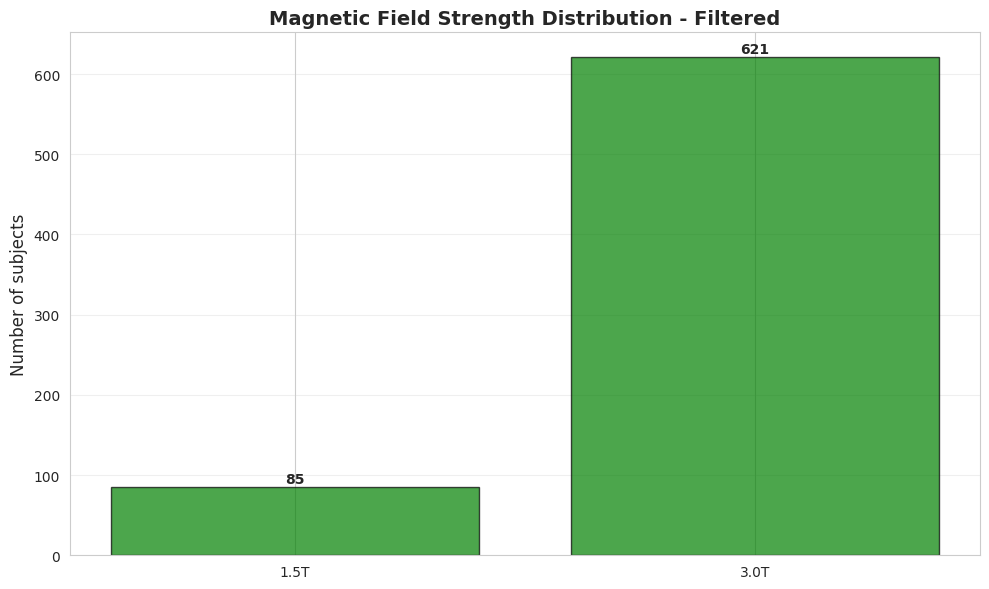

In [19]:
# Field strength distribution (if available)
if data_filtered['MagneticFieldStrength'].notna().sum() > 0:
    fig, ax = plt.subplots(figsize=(10, 6))
    fs_filtered = data_filtered['MagneticFieldStrength'].dropna()
    fs_counts = fs_filtered.value_counts().sort_index()
    
    ax.bar(range(len(fs_counts)), fs_counts.values, color='green', edgecolor='black', alpha=0.7)
    ax.set_xticks(range(len(fs_counts)))
    ax.set_xticklabels([f'{fs:.1f}T' for fs in fs_counts.index])
    ax.set_ylabel('Number of subjects', fontsize=12)
    ax.set_title('Magnetic Field Strength Distribution - Filtered', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    for i, v in enumerate(fs_counts.values):
        ax.text(i, v + 5, f'{v:,}', ha='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("Field strength visualization skipped (no MRI info loaded)")

## 10. Export Filtered Data

In [20]:
# Prepare export dataframe with standardized columns
print("Preparing export data...")

# Create standardized output dataframe
output_df = pd.DataFrame({
    'subject_id': data_filtered['participant_id'].values,
    'session_id': data_filtered['session_id'].values,
    'age': data_filtered['age'].values,
    'sex': data_filtered['sex'].values,
    'site': data_filtered['dataset'].values,  # Use full dataset name as site
    'dataset_code': data_filtered['dataset_code'].values,  # Keep original dataset code
    'dataset': 'FOMO-300K'  # Overall dataset name
})

# Add field strength if available
if 'MagneticFieldStrength' in data_filtered.columns:
    output_df['field_strength_T'] = data_filtered['MagneticFieldStrength'].values
else:
    output_df['field_strength_T'] = np.nan
    print("Warning: field_strength_T not available in current data")

# Sort by dataset_code and subject_id
output_df = output_df.sort_values(['dataset_code', 'subject_id']).reset_index(drop=True)

print(f"\nExport dataframe prepared: {len(output_df):,} subjects")
print(f"Columns: {list(output_df.columns)}")
print(f"\nFirst 10 rows:")
print(output_df.head(10))

Preparing export data...

Export dataframe prepared: 859 subjects
Columns: ['subject_id', 'session_id', 'age', 'sex', 'site', 'dataset_code', 'dataset', 'field_strength_T']

First 10 rows:
  subject_id session_id   age sex                site dataset_code    dataset  \
0     sub-03     ses-01  57.0   F  PT001_ClevelandCCF        PT001  FOMO-300K   
1     sub-04     ses-01  45.0   F  PT001_ClevelandCCF        PT001  FOMO-300K   
2     sub-06     ses-01  52.0   F  PT001_ClevelandCCF        PT001  FOMO-300K   
3     sub-07     ses-01  51.0   M  PT001_ClevelandCCF        PT001  FOMO-300K   
4     sub-08     ses-01  56.0   F  PT001_ClevelandCCF        PT001  FOMO-300K   
5     sub-09     ses-01  56.0   M  PT001_ClevelandCCF        PT001  FOMO-300K   
6     sub-10     ses-01  55.0   M  PT001_ClevelandCCF        PT001  FOMO-300K   
7     sub-14     ses-01  48.0   M  PT001_ClevelandCCF        PT001  FOMO-300K   
8     sub-16     ses-01  60.0   F  PT001_ClevelandCCF        PT001  FOMO-300K   
9

In [21]:
# Identify and exclude overlapping datasets
print("=" * 80)
print("IDENTIFYING OVERLAPPING DATASETS")
print("=" * 80)

# Datasets already processed separately in this project
already_processed = {
    'PT021_IXI': 'IXI (already processed separately)',
    'PT028_OASIS1': 'OASIS1 (included in OASIS combined)',
    'PT029_OASIS2': 'OASIS2 (included in OASIS combined)', 
    # Add HCP components from AABC if identified
    # PT0XX_HCP: 'HCP (subset in AABC)',
}

print("\nDatasets to exclude (already in project):")
for code, reason in already_processed.items():
    if code.split('_')[0] in output_df['dataset_code'].unique():
        n_subjects = (output_df['dataset_code'] == code.split('_')[0]).sum()
        print(f"  {code}: {n_subjects} subjects - {reason}")

# Filter out overlapping datasets
print("\n" + "=" * 80)
print("FILTERING OUT OVERLAPPING DATASETS")
print("=" * 80)

exclude_codes = [code.split('_')[0] for code in already_processed.keys()]
output_df_unique = output_df[~output_df['dataset_code'].isin(exclude_codes)].copy()

print(f"\nBefore exclusion: {len(output_df):,} subjects")
print(f"Excluded subjects: {len(output_df) - len(output_df_unique):,}")
print(f"After exclusion: {len(output_df_unique):,} subjects")

print("\nRemaining datasets:")
remaining_counts = output_df_unique['dataset_code'].value_counts().sort_values(ascending=False)
for dataset, count in remaining_counts.items():
    print(f"  {dataset}: {count:,} subjects")

# Update output_df to unique only
output_df = output_df_unique.copy()

IDENTIFYING OVERLAPPING DATASETS

Datasets to exclude (already in project):

FILTERING OUT OVERLAPPING DATASETS

Before exclusion: 859 subjects
Excluded subjects: 0
After exclusion: 859 subjects

Remaining datasets:
  PT030: 526 subjects
  PT014: 190 subjects
  PT034: 81 subjects
  PT032: 20 subjects
  PT033: 19 subjects
  PT001: 15 subjects
  PT036: 8 subjects


In [22]:
# Export overall filtered dataset
output_path_overall = 'data/FOMO-300K/fomo_healthy_controls_age45plus.csv'
output_df.to_csv(output_path_overall, index=False)
print(f"✓ Exported {len(output_df):,} subjects to: {output_path_overall}")

✓ Exported 859 subjects to: data/FOMO-300K/fomo_healthy_controls_age45plus.csv


In [23]:
# Export per-dataset CSVs
print("\nExporting per-dataset files...")
export_stats = []

for dataset_code in sorted(output_df['dataset_code'].unique()):
    dataset_data = output_df[output_df['dataset_code'] == dataset_code].copy()
    
    # Create filename
    output_path = f'data/FOMO-300K/fomo_{dataset_code}_controls_age45plus.csv'
    dataset_data.to_csv(output_path, index=False)
    
    # Collect statistics
    stats = {
        'dataset_code': dataset_code,
        'n_subjects': len(dataset_data),
        'age_mean': dataset_data['age'].mean(),
        'age_std': dataset_data['age'].std(),
        'age_min': dataset_data['age'].min(),
        'age_max': dataset_data['age'].max(),
        'n_female': (dataset_data['sex'] == 'F').sum(),
        'n_male': (dataset_data['sex'] == 'M').sum(),
        'pct_female': (dataset_data['sex'] == 'F').sum() / len(dataset_data) * 100
    }
    export_stats.append(stats)
    
    print(f"  ✓ {dataset_code}: {len(dataset_data):4,} subjects → {output_path}")

# Create summary dataframe
export_summary_df = pd.DataFrame(export_stats)
print(f"\nTotal datasets exported: {len(export_stats)}")


Exporting per-dataset files...
  ✓ PT001:   15 subjects → data/FOMO-300K/fomo_PT001_controls_age45plus.csv
  ✓ PT014:  190 subjects → data/FOMO-300K/fomo_PT014_controls_age45plus.csv
  ✓ PT030:  526 subjects → data/FOMO-300K/fomo_PT030_controls_age45plus.csv
  ✓ PT032:   20 subjects → data/FOMO-300K/fomo_PT032_controls_age45plus.csv
  ✓ PT033:   19 subjects → data/FOMO-300K/fomo_PT033_controls_age45plus.csv
  ✓ PT034:   81 subjects → data/FOMO-300K/fomo_PT034_controls_age45plus.csv
  ✓ PT036:    8 subjects → data/FOMO-300K/fomo_PT036_controls_age45plus.csv

Total datasets exported: 7


In [24]:
# Save summary statistics to JSON
summary_json = {
    'dataset': 'FOMO-300K',
    'filter_criteria': {
        'group': 'Control',
        'age_min': 45,
        'field_strength_allowed': [1.5, 3.0],
        'session': 'first_only',
        'excluded_datasets': excluded_datasets if excluded_datasets else None
    },
    'total_subjects': len(output_df),
    'age': {
        'mean': float(output_df['age'].mean()),
        'std': float(output_df['age'].std()),
        'min': int(output_df['age'].min()),
        'max': int(output_df['age'].max()),
        'median': float(output_df['age'].median())
    },
    'sex': {
        'female': int((output_df['sex'] == 'F').sum()),
        'male': int((output_df['sex'] == 'M').sum()),
        'female_pct': float((output_df['sex'] == 'F').sum() / len(output_df) * 100)
    },
    'datasets': {
        'n_datasets': int(output_df['dataset_code'].nunique()),
        'datasets': export_summary_df.to_dict('records')
    },
    'export_date': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}

summary_path = 'data/FOMO-300K/fomo_filtering_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary_json, f, indent=2)

print(f"\n✓ Summary statistics saved to: {summary_path}")


✓ Summary statistics saved to: data/FOMO-300K/fomo_filtering_summary.json


## 10c. Lista soggetti (per run_kube_job)

Questa sezione crea una lista verificata di soggetti con file disponibili e genera un CSV compatibile con `run_kube_job` (colonne: `subject_id`, `image_path`, `output_path`). L'`output_path` segue lo standard BIDS in `derivatives/fastsurfer` o `derivatives/synthseg` in base alla variabile `processing` e include anche il check di quanti soggetti risultano gia elaborati in `fastsurfer`, `synthseg` e in entrambi i metodi.

Puoi impostare una tra `download_index_csv` o `bids_root` come sorgente principale dei path.

In [25]:
from pathlib import Path
import pandas as pd

# === CONFIGURA QUI ===
processing = "fastsurfer"
processing_methods = ("fastsurfer", "synthseg")  # Metodi da valutare come "gia elaborati"
download_index_csv = Path("data/FOMO-300K/pacs_index.csv")  # opzionale: CSV con colonne subject_id, image_path
bids_root = Path("/mnt/NAS-Progetti/BrainAtrophy/Normative Model/FOMO")  # opzionale: root BIDS (ds-*/sub-*/ses-*/anat)
derivatives_roots = {m: bids_root / "derivatives" / m for m in processing_methods}
derivatives_root = derivatives_roots[processing]
output_csv = Path("data/FOMO-300K/fomo_to_process.csv")

# Se output_df non e in memoria, caricalo dalla CSV gia esportata
if "output_df" not in globals():
    fallback_csv = Path("data/FOMO-300K/fomo_healthy_controls_age45plus.csv")
    if not fallback_csv.exists():
        raise FileNotFoundError("Manca output_df e non trovo data/FOMO-300K/fomo_healthy_controls_age45plus.csv")
    output_df = pd.read_csv(fallback_csv)

def normalize_sub(value: str) -> str:
    value = str(value).strip()
    return value if value.startswith("sub-") else f"sub-{value}"

def normalize_ses(value: str) -> str:
    value = str(value).strip()
    return value if value.startswith("ses-") else f"ses-{value}"

def normalize_ds(value: str) -> str:
    value = str(value).strip()
    return value if value.startswith("ds-") else f"ds-{value}"

def pick_existing(paths):
    for p in paths:
        if p.exists():
            return p
    return None

def build_bids_path(row: pd.Series) -> Path | None:
    subject = normalize_sub(row["subject_id"])
    ds = normalize_ds(row.get("dataset_code", "FOMO"))
    ses = None
    if "session_id" in row and pd.notna(row["session_id"]):
        ses = normalize_ses(row["session_id"])

    base = bids_root / ds / subject
    if ses:
        base = base / ses
    anat_dir = base / "anat"
    if not anat_dir.exists():
        return None

    if ses:
        candidates = [
            anat_dir / f"{subject}_{ses}_T1w.nii.gz",
            anat_dir / f"{subject}_{ses}_T1w.nii",
        ]
        glob_candidates = list(anat_dir.glob(f"{subject}_{ses}_*T1w.nii*"))
    else:
        candidates = [
            anat_dir / f"{subject}_T1w.nii.gz",
            anat_dir / f"{subject}_T1w.nii",
        ]
        glob_candidates = list(anat_dir.glob(f"{subject}_*T1w.nii*"))

    picked = pick_existing(candidates)
    if picked:
        return picked
    return sorted(glob_candidates)[0] if glob_candidates else None

def make_output_path(row: pd.Series, method: str = processing) -> Path:
    subject = normalize_sub(row["subject_id"])
    ds = normalize_ds(row.get("dataset_code", "FOMO"))
    ses = None
    if "session_id" in row and pd.notna(row["session_id"]):
        ses = normalize_ses(row["session_id"])
    base = derivatives_roots[method] / ds / subject
    if ses:
        base = base / ses
    return base

def count_processed_subjects(df: pd.DataFrame, method: str) -> set[str]:
    root = derivatives_roots[method]
    if not root.exists() or df.empty:
        return set()
    processed = set()
    for _, row in df.iterrows():
        sid = str(row["subject_id"])
        out_dir = make_output_path(row, method=method)
        if out_dir.exists():
            processed.add(sid)
    return processed

records = []
missing = []

if download_index_csv.exists():
    download_index = pd.read_csv(download_index_csv)
    col_subject = "subject_id" if "subject_id" in download_index.columns else None
    col_image = "image_path" if "image_path" in download_index.columns else None
    if col_subject is None or col_image is None:
        raise ValueError("download_index_csv deve avere colonne: subject_id, image_path")

    merged = output_df.merge(download_index[[col_subject, col_image]], left_on="subject_id", right_on=col_subject, how="left")
    for _, row in merged.iterrows():
        image_path = Path(row[col_image]) if pd.notna(row[col_image]) else None
        if image_path and image_path.exists():
            records.append({
                "subject_id": str(row["subject_id"]),
                "image_path": str(image_path),
                "output_path": str(make_output_path(row, method=processing)),
                "dataset_code": row.get("dataset_code", "FOMO"),
                "session_id": row.get("session_id", None),
            })
        else:
            missing.append(str(row["subject_id"]))
elif bids_root.exists():
    for _, row in output_df.iterrows():
        image_path = build_bids_path(row)
        if image_path:
            records.append({
                "subject_id": str(row["subject_id"]),
                "image_path": str(image_path),
                "output_path": str(make_output_path(row, method=processing)),
                "dataset_code": row.get("dataset_code", "FOMO"),
                "session_id": row.get("session_id", None),
            })
        else:
            missing.append(str(row["subject_id"]))
else:
    raise FileNotFoundError("Configura download_index_csv o bids_root con un percorso valido.")

pacs_list_df = pd.DataFrame(records)
if not pacs_list_df.empty:
    cols = ["subject_id", "image_path", "output_path", "dataset_code", "session_id"]
    existing_cols = [c for c in cols if c in pacs_list_df.columns]
    pacs_list_df = pacs_list_df[existing_cols]
    pacs_list_df.to_csv(output_csv, index=False)

processed_by_method = {m: count_processed_subjects(pacs_list_df, m) for m in processing_methods}
processed_both = set.intersection(*(processed_by_method[m] for m in processing_methods)) if not pacs_list_df.empty else set()
subject_ids = pacs_list_df["subject_id"].astype(str).tolist() if not pacs_list_df.empty else []

print("=" * 80)
print("FOMO: PACS verificati")
print(f"Totale soggetti: {len(output_df):,}")
print(f"Con PACS validi: {len(pacs_list_df):,}")
print(f"Senza PACS: {len(missing):,}")
print(f"CSV export: {output_csv}")
print("-" * 80)
print("Stato elaborazione su soggetti con PACS valido:")
for method in processing_methods:
    n_processed = len(processed_by_method[method])
    pct = (100.0 * n_processed / len(subject_ids)) if subject_ids else 0.0
    print(f"- {method}: {n_processed:,}/{len(subject_ids):,} ({pct:.1f}%)")
both_pct = (100.0 * len(processed_both) / len(subject_ids)) if subject_ids else 0.0
print(f"- entrambi ({' + '.join(processing_methods)}): {len(processed_both):,}/{len(subject_ids):,} ({both_pct:.1f}%)")

if not pacs_list_df.empty and "dataset_code" in pacs_list_df.columns:
    print("\nDistribuzione per dataset (PACS validi):")
    ds_counts = pacs_list_df["dataset_code"].value_counts().sort_index()
    for ds, count in ds_counts.items():
        print(f"  {ds}: {count:,}")
print("=" * 80)

FOMO: PACS verificati
Totale soggetti: 859
Con PACS validi: 850
Senza PACS: 9
CSV export: data/FOMO-300K/fomo_to_process.csv
--------------------------------------------------------------------------------
Stato elaborazione su soggetti con PACS valido:
- fastsurfer: 708/850 (83.3%)
- synthseg: 708/850 (83.3%)
- entrambi (fastsurfer + synthseg): 708/850 (83.3%)

Distribuzione per dataset (PACS validi):
  PT001: 15
  PT014: 190
  PT030: 517
  PT032: 20
  PT033: 19
  PT034: 81
  PT036: 8
